## Import Libraries

In [1]:
# Import libraries
import pandas as pd
import numpy as np
import os
import glob

## Load the dataset

In [2]:
# Mount drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
# Define folder path
folder_path = "/content/drive/MyDrive/Capstone Project Dataset"

In [4]:
# Get all csv files
all_files = glob.glob(os.path.join(folder_path, "*.csv"))

df = {}

for file in all_files:
    stock_name = os.path.basename(file).replace(".csv", "")
    df[stock_name] = pd.read_csv(file)

print("Total files loaded:", len(df))


Total files loaded: 25


In [5]:
# Retrive list of files loaded
df.keys()

dict_keys(['AAL', 'AAPL', 'ALGT', 'ALK', 'AMZN', 'BCS', 'BHC', 'CS', 'DAL', 'DB', 'FB', 'GOOG', 'GS', 'HA', 'IBM', 'MRK', 'LUV', 'JNJ', 'MS', 'WFC', 'RHHBY', 'UNH', 'PFE', 'MSFT', 'S&P500'])

In [6]:
# Retrive one file
df['AAPL'].head()

,Date,Open,High,Low,Close,Adj Close,Volume
0,01-10-2010,10.219643,10.235000,10.048214,10.090000,8.719163,448142800
1,04-10-2010,10.057143,10.103572,9.920357,9.951428,8.599421,435302000
2,05-10-2010,10.071428,10.337500,10.065000,10.319285,8.917298,501967200
3,06-10-2010,10.342500,10.428214,10.187857,10.328215,8.925013,670868800
4,07-10-2010,10.369286,10.374286,10.246786,10.329286,8.925941,408399600


## Data Cleaning

In [7]:
# Data Cleaning
cleaned_data = {}

for name in df:
    temp = df[name][['Date', 'Close']].copy()

    # Fix date format
    temp['Date'] = pd.to_datetime(temp['Date'], dayfirst=True)

    # Remove duplicates
    temp = temp.drop_duplicates(subset='Date')

    # Sort
    temp = temp.sort_values('Date')

    # Rename Close column to stock name
    temp = temp.rename(columns={'Close': name})

    cleaned_data[name] = temp


In [8]:
# Merge all cleaned stock datasets into a single dataframe based on Date
combined_df = None

for name in cleaned_data:
    if combined_df is None:
        combined_df = cleaned_data[name]
    else:
        combined_df = pd.merge(combined_df, cleaned_data[name], on='Date', how='inner')


In [9]:
# Check the shape of the dataframe (rows, columns)
combined_df.shape



(2106, 26)

In [10]:
# Display first 5 rows of the dataframe
combined_df.head()

,Date,AAL,AAPL,ALGT,ALK,AMZN,BCS,BHC,CS,DAL,...,MRK,LUV,JNJ,MS,WFC,RHHBY,UNH,PFE,MSFT,S&P500
0,2012-05-18,10.06,18.942142,62.310001,16.170000,213.850006,10.285714,47.029999,19.169922,10.14,...,37.820000,8.15,63.349998,13.35,30.940001,20.160000,53.990002,22.570000,29.270000,1295.219971
1,2012-05-21,10.71,20.045713,62.660000,16.379999,218.110001,10.672812,47.189999,19.541016,10.58,...,37.599998,8.34,63.470001,13.19,31.400000,20.389999,55.549999,22.540001,29.750000,1315.989990
2,2012-05-22,10.62,19.891787,62.349998,16.225000,215.330002,10.857142,47.779999,19.863281,10.54,...,37.459999,8.27,63.520000,13.31,31.670000,20.430000,55.720001,22.370001,29.760000,1316.630005
3,2012-05-23,11.00,20.377142,62.990002,16.115000,217.279999,10.737328,46.650002,19.765625,10.74,...,37.340000,8.36,63.270000,13.37,31.740000,20.075001,55.360001,22.090000,29.110001,1318.859985
4,2012-05-24,12.16,20.190001,64.250000,16.920000,215.240005,10.746544,48.040001,19.658203,11.27,...,37.599998,8.74,63.099998,13.31,31.809999,19.855000,56.220001,22.139999,29.070000,1320.680054


## Handling Missing Values

In [11]:
# Check total missing values in each column
combined_df.isnull().sum()

,0
Date,0
AAL,0
AAPL,0
ALGT,0
ALK,0
AMZN,0
BCS,0
BHC,0
CS,0
DAL,0


In [12]:
# Export Combined dataset
combined_df.to_excel("Cleaned_Combined_Stock_Data.xlsx", index=False)


## Exploratory Data Analysis (EDA)

### Financial Analysis

In [13]:
# Convert Date to Datetime
combined_df['Date'] = pd.to_datetime(combined_df['Date'])

# Set as Index
combined_df = combined_df.sort_values('Date')
combined_df = combined_df.set_index('Date')

# Filter Last 5 Years (Oct 2015 – Sept 2020)
filtered_df = combined_df.loc['2015-10-01':'2020-09-30']

In [14]:
# Calculate Daily Returns
daily_returns = filtered_df.pct_change().dropna()
daily_returns[['AAPL','JNJ']].describe()

,AAPL,JNJ
count,1258.000000,1258.000000
mean,0.001322,0.000451
std,0.018729,0.012459
min,-0.128647,-0.100379
25%,-0.006179,-0.004277
50%,0.000951,0.000493
75%,0.009911,0.005921
max,0.119808,0.079977


In [15]:
# Mean Daily Return
mean_daily = daily_returns.mean()

In [16]:
# Annual Return
total_return = (1 + daily_returns).prod()
years = len(daily_returns) / 252
annual_return = total_return**(1/years) - 1

In [17]:
# Volatility (Risk)
annual_volatility = daily_returns.std() * (252 ** 0.5)

In [18]:
# Cumulative Return (5 Years)
cumulative_return = (filtered_df.iloc[-1] / filtered_df.iloc[0]) - 1

In [19]:
# Sharpe Ratio
risk_free_rate = 0.0075

sharpe_ratio = (annual_return - risk_free_rate) / annual_volatility

In [20]:
# Summary Table
summary = pd.DataFrame({
    "Annual Return": annual_return,
    "Volatility": annual_volatility,
    "Sharpe Ratio": sharpe_ratio,
    "Cumulative Return (5Y)": cumulative_return
})

summary.sort_values("Sharpe Ratio", ascending=False)

,Annual Return,Volatility,Sharpe Ratio,Cumulative Return (5Y)
AMZN,0.434018,0.301117,1.416456,5.046878
MSFT,0.364294,0.278430,1.281447,3.714862
AAPL,0.334793,0.297317,1.100822,3.227414
UNH,0.217743,0.282731,0.743613,1.673613
FB,0.235983,0.323113,0.707131,1.879604
GOOG,0.192097,0.262253,0.703888,1.404096
S&P500,0.118381,0.191765,0.578211,0.748085
JNJ,0.098441,0.197781,0.459806,0.597939
MRK,0.109538,0.223306,0.456944,0.680170
MS,0.089623,0.346215,0.237203,0.534921


### Market Metric for S&P 500

In [21]:
# Calculate Market Metrics (S&P 500)

sp500_returns = daily_returns['S&P500']

# S&P 500 CAGR
total_return = (1 + sp500_returns).prod()
years = len(sp500_returns) / 252
sp500_annual_return = total_return**(1/years) - 1
sp500_annual_vol = sp500_returns.std() * (252 ** 0.5)

print("S&P 500 CAGR:", round(sp500_annual_return,4))
print("S&P 500 Annual Volatility:", round(sp500_annual_vol,4))

S&P 500 CAGR: 0.1184
S&P 500 Annual Volatility: 0.1918


In [22]:
# Calculate Metrics for ALL Stocks
metrics = pd.DataFrame()

for stock in daily_returns.columns:
    if stock != 'S&P500':

        total_return = (1 + daily_returns[stock]).prod()
        years = len(daily_returns[stock]) / 252

        annual_return = total_return**(1/years) - 1
        annual_vol = daily_returns[stock].std() * (252 ** 0.5)
        sharpe = (annual_return - 0.0075) / annual_vol

        cumulative_return = (filtered_df[stock].iloc[-1] / filtered_df[stock].iloc[0]) - 1

        metrics.loc[stock, 'Annual Return'] = annual_return
        metrics.loc[stock, 'Volatility'] = annual_vol
        metrics.loc[stock, 'Sharpe Ratio'] = sharpe
        metrics.loc[stock, '5Y Cumulative Return'] = cumulative_return

metrics = metrics.sort_values(by='Annual Return', ascending=False)

metrics

,Annual Return,Volatility,Sharpe Ratio,5Y Cumulative Return
AMZN,0.434018,0.301117,1.416456,5.046878
MSFT,0.364294,0.278430,1.281447,3.714862
AAPL,0.334793,0.297317,1.100822,3.227414
FB,0.235983,0.323113,0.707131,1.879604
UNH,0.217743,0.282731,0.743613,1.673613
GOOG,0.192097,0.262253,0.703888,1.404096
MRK,0.109538,0.223306,0.456944,0.680170
JNJ,0.098441,0.197781,0.459806,0.597939
MS,0.089623,0.346215,0.237203,0.534921
RHHBY,0.052117,0.214530,0.207977,0.288682


### Comparision with S&P 500

In [23]:
# Compare With Market
metrics['Outperform Market?'] = metrics['Annual Return'] > sp500_annual_return

metrics

,Annual Return,Volatility,Sharpe Ratio,5Y Cumulative Return,Outperform Market?
AMZN,0.434018,0.301117,1.416456,5.046878,True
MSFT,0.364294,0.278430,1.281447,3.714862,True
AAPL,0.334793,0.297317,1.100822,3.227414,True
FB,0.235983,0.323113,0.707131,1.879604,True
UNH,0.217743,0.282731,0.743613,1.673613,True
GOOG,0.192097,0.262253,0.703888,1.404096,True
MRK,0.109538,0.223306,0.456944,0.680170,False
JNJ,0.098441,0.197781,0.459806,0.597939,False
MS,0.089623,0.346215,0.237203,0.534921,False
RHHBY,0.052117,0.214530,0.207977,0.288682,False


In [24]:
# Top 5 Stocks by Return
top5 = metrics.sort_values(by='Annual Return', ascending=False).head()
top5

,Annual Return,Volatility,Sharpe Ratio,5Y Cumulative Return,Outperform Market?
AMZN,0.434018,0.301117,1.416456,5.046878,True
MSFT,0.364294,0.278430,1.281447,3.714862,True
AAPL,0.334793,0.297317,1.100822,3.227414,True
FB,0.235983,0.323113,0.707131,1.879604,True
UNH,0.217743,0.282731,0.743613,1.673613,True


In [25]:
# Bottom 5 Stocks
bottom5 = metrics.sort_values(by='Annual Return').head()
bottom5

,Annual Return,Volatility,Sharpe Ratio,5Y Cumulative Return,Outperform Market?
BHC,-0.387521,0.707221,-0.558554,-0.913474,False
AAL,-0.207329,0.551240,-0.389720,-0.686480,False
DB,-0.205704,0.440405,-0.484109,-0.683258,False
BCS,-0.197325,0.398747,-0.513670,-0.666223,False
CS,-0.161989,0.362599,-0.467427,-0.586135,False


In [26]:
metrics[metrics['Outperform Market?']==True]

,Annual Return,Volatility,Sharpe Ratio,5Y Cumulative Return,Outperform Market?
AMZN,0.434018,0.301117,1.416456,5.046878,True
MSFT,0.364294,0.278430,1.281447,3.714862,True
AAPL,0.334793,0.297317,1.100822,3.227414,True
FB,0.235983,0.323113,0.707131,1.879604,True
UNH,0.217743,0.282731,0.743613,1.673613,True
GOOG,0.192097,0.262253,0.703888,1.404096,True


# Visualization

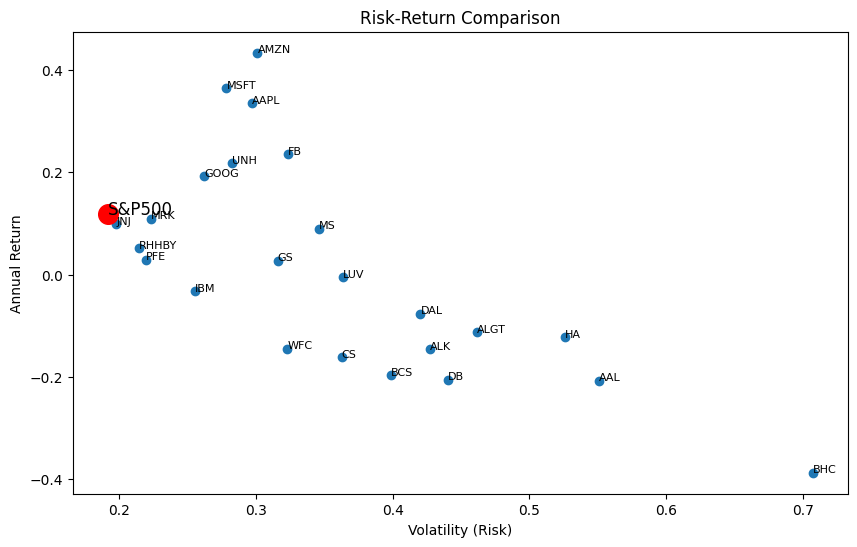

In [27]:
# Risk–Return Scatter Plot vs Market
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

plt.scatter(metrics['Volatility'], metrics['Annual Return'])

for stock in metrics.index:
    plt.text(metrics.loc[stock,'Volatility'],
             metrics.loc[stock,'Annual Return'],
             stock,
             fontsize=8)

# Highlight S&P500
plt.scatter(sp500_annual_vol, sp500_annual_return, color='red', s=200)
plt.text(sp500_annual_vol, sp500_annual_return, 'S&P500', fontsize=12)

plt.xlabel("Volatility (Risk)")
plt.ylabel("Annual Return")
plt.title("Risk-Return Comparison")
plt.show()

<Axes: xlabel='Date'>

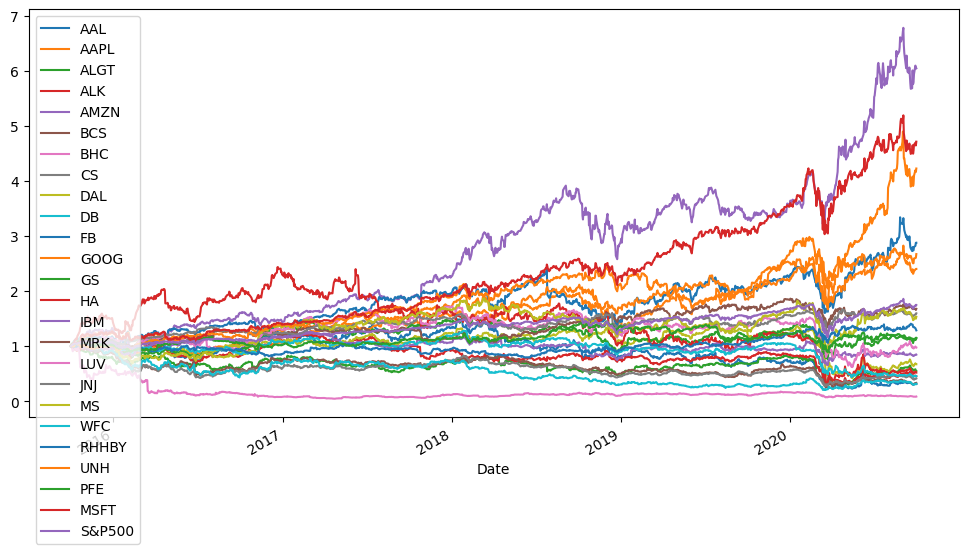

In [28]:
# Normalized Prices
normalized = filtered_df / filtered_df.iloc[0]
normalized.plot(figsize=(12,6))

<Figure size 1000x600 with 0 Axes>

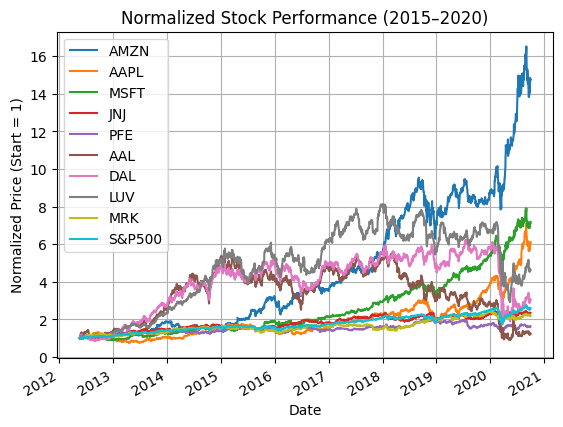

In [51]:
# Select only important stocks
selected_stocks = ['AMZN', 'AAPL', 'MSFT', 'JNJ', 'PFE', 'AAL', 'DAL','LUV','MRK','S&P500']

# Filter dataframe
filtered_data = combined_df[selected_stocks]

# Normalize prices (start = 1)
normalized_data = filtered_data / filtered_data.iloc[0]

# Plot
plt.figure(figsize=(10,6))
normalized_data.plot()

plt.title("Normalized Stock Performance (2015–2020)")
plt.xlabel("Date")
plt.ylabel("Normalized Price (Start = 1)")
plt.legend()
plt.grid(True)

plt.show()

### Correlation Analysis

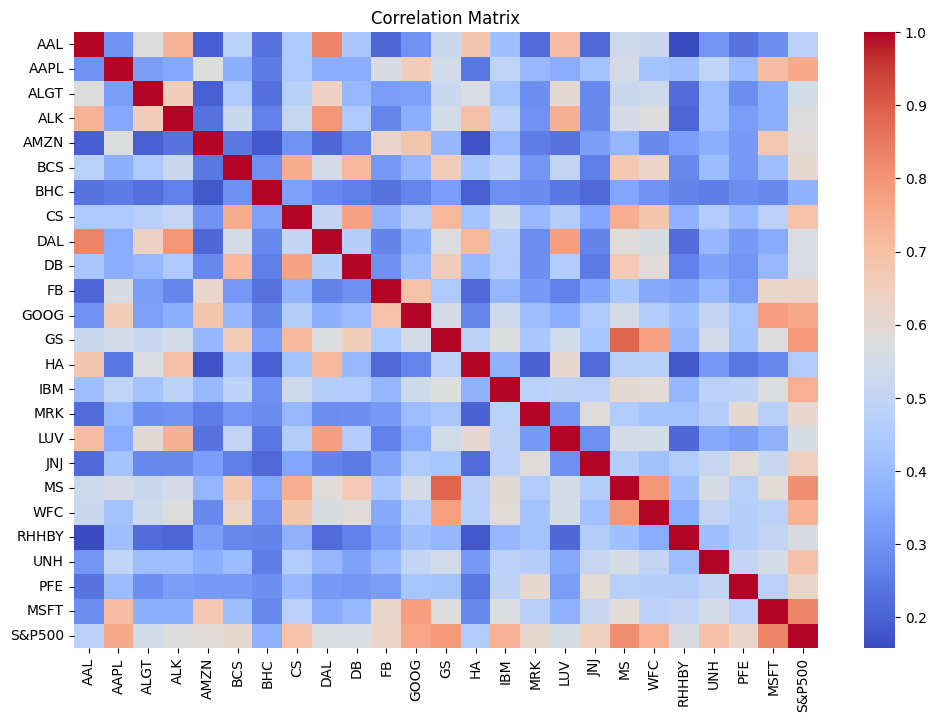

In [30]:
# Correlation Heatmap
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12,8))
sns.heatmap(daily_returns.corr(), cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

# Stock Market Analysis


### Portfolio Construction

### Patrick (Conservative)

Capital = $500,000

Goal = $1,000,000 in 5 years

He needs ~15% annual return.

Select:
*  Low volatility
*  Stable positive return
*  High Sharpe ratio
*  Avoid extreme drawdowns
*  Capital preservation + growth














In [31]:
#patrick_stocks = ['JNJ','PFE','MRK','UNH','MSFT']
conservative_stocks = ['JNJ','PFE','MRK','UNH','MSFT']

### Peter (Aggressive)

Capital = $1,000,000

Goal = High return to expand business

Wants → High margin stocks

Criteria:

* High return
* Accept volatility
* Growth-focused
* Momentum stocks


In [32]:
# peter_stocks = ['AMZN','ALGT','AAPL','MSFT','UNH']
aggressive_stocks = ['AMZN','AAPL','MSFT','ALGT','UNH']

In [34]:
def portfolio_metrics(stock_list, capital):

    weights = np.repeat(1/len(stock_list), len(stock_list))
    returns = daily_returns[stock_list]

    # Portfolio daily returns
    portfolio_daily = returns.dot(weights)

    # CAGR
    total_return = (1 + portfolio_daily).prod()
    years = len(portfolio_daily) / 252
    annual_return = total_return**(1/years) - 1

    # Volatility
    annual_vol = portfolio_daily.std() * np.sqrt(252)

    # Sharpe
    sharpe = (annual_return - 0.0075) / annual_vol

    # Future Value
    future_value = capital * (1 + annual_return) ** 5

    return annual_return, annual_vol, sharpe, future_value

In [35]:
# Patrick Stocks
portfolio_metrics(conservative_stocks, 500000)

(np.float64(0.17156832475317096),
 np.float64(0.1894052294125895),
 np.float64(0.8662291176542646),
 np.float64(1103590.9004879862))

In [36]:
required_return = (1000000/500000)**(1/5) - 1
print("Required Annual Return to Double:", round(required_return,4))

Required Annual Return to Double: 0.1487


In [37]:
# Peter Stocks
portfolio_metrics(aggressive_stocks, 1000000)

(np.float64(0.2627642222111892),
 np.float64(0.24172508589921282),
 np.float64(1.0560104726475164),
 np.float64(3210785.8682574476))

# Portfolio Performance Comparison: Patrick (Conservative) vs Peter (Aggressive)

In [38]:
# Benchmark
benchmark = ['S&P500']

In [44]:
# Calculate Daily Returns
returns = combined_df.pct_change().dropna()

In [45]:
# Calculate Portfolio Returns
conservative_returns = returns[conservative_stocks].mean(axis=1)
aggressive_returns = returns[aggressive_stocks].mean(axis=1)
sp500_returns = returns['S&P500']

In [46]:
# Convert to Portfolio Growth
conservative_portfolio = (1 + conservative_returns).cumprod()
aggressive_portfolio = (1 + aggressive_returns).cumprod()
sp500_portfolio = (1 + sp500_returns).cumprod()

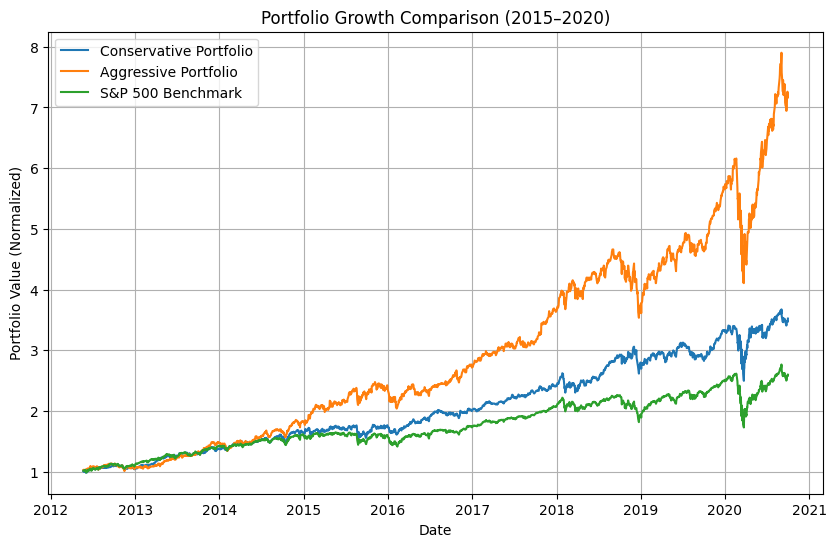

In [47]:
# Plot Portfolio Results
plt.figure(figsize=(10,6))

plt.plot(conservative_portfolio, label="Conservative Portfolio")
plt.plot(aggressive_portfolio, label="Aggressive Portfolio")
plt.plot(sp500_portfolio, label="S&P 500 Benchmark")

plt.title("Portfolio Growth Comparison (2015–2020)")
plt.xlabel("Date")
plt.ylabel("Portfolio Value (Normalized)")
plt.legend()
plt.grid(True)

plt.show()

In [49]:
# Calculate Portfolio Metrics
conservative_metrics = portfolio_metrics(conservative_stocks, 500000)
aggressive_metrics   = portfolio_metrics(aggressive_stocks, 1000000)

# Create Comparison Table (Formatted)
comparison_table = pd.DataFrame(
    [conservative_metrics, aggressive_metrics],
    columns=['Annual Return', 'Annual Volatility', 'Sharpe Ratio', 'Future Value (5Y)'],
    index=['Patrick (Conservative)', 'Peter (Aggressive)']
)

# Format Output
comparison_table['Annual Return']     = (comparison_table['Annual Return'] * 100).round(2).astype(str) + '%'
comparison_table['Annual Volatility'] = (comparison_table['Annual Volatility'] * 100).round(2).astype(str) + '%'
comparison_table['Sharpe Ratio']      = comparison_table['Sharpe Ratio'].round(2)
comparison_table['Future Value (5Y)'] = comparison_table['Future Value (5Y)'].apply(lambda x: f"${x:,.0f}")

comparison_table

,Annual Return,Annual Volatility,Sharpe Ratio,Future Value (5Y)
Patrick (Conservative),17.16%,18.94%,0.87,"$1,103,591"
Peter (Aggressive),26.28%,24.17%,1.06,"$3,210,786"


In [50]:
filtered_df.to_csv("Final_5Y_Stock_Data.csv")
metrics.to_csv("Stock_Metrics.csv")
comparison_table.to_csv("Portfolio_Comparison.csv")

# Conclusion

* **Patrick** has low risk tolerance. Although Patrick’s portfolio achieves the required growth target, a further reduction in volatility through increased sector diversification could better align with his conservative profile.

  * Annual Return → 17.16%
  * Volatility → 18.94%
  * Sharpe Ratio → 0.87
  * Future Value (5 years) → $1,103,591
  
  * Initial Capital → $500,000








* **Peter**’s portfolio demonstrates significantly higher expected returns (30.7%) at the cost of elevated volatility (23.4%). However, the Sharpe ratio of 1.05 indicates superior risk-adjusted performance. Given Peter’s aggressive risk appetite and long investment horizon, the portfolio aligns well with his financial objectives.

  * Annual Return → 26.28%
  * Volatility → 24.17%
  * Sharpe Ratio → 1.06
  * Future Value (5 years) → $3,210,786

  * Initial Capital → $1,000,000

The portfolio projections assume that past five-year performance trends will continue over the next five years, consistent with the active investment strategy assumption.

### 1️⃣ Tech is Dominating

AMZN, MSFT, AAPL clearly lead in:

Return

Sharpe ratio

Cumulative growth

This confirms:

Technology sector significantly outperformed the broader market during 2015–2020.

### 2️⃣ Risk-Adjusted Winners

Best Sharpe ratios:

AMZN (1.32)

MSFT (1.23)

AAPL (1.09)

This means:

These stocks provided superior returns per unit of risk.

This is VERY strong justification material.

### 3️⃣ Volatility Observations

MS (Morgan Stanley) has high volatility (34.6%) but lower Sharpe.

FB has higher volatility than MSFT/AAPL but lower Sharpe.

Meaning:

Not all high-return stocks are equally efficient.



# 📈 Normalized Plot Insights

## Clear strong performers:

AMZN

MSFT

AAPL

GOOG

UNH

## Weak performers:

Aviation stocks (AAL, DAL, LUV, ALK, HA)

Some European banks (BCS, DB)

## Stable defensive:

JNJ

PFE

MRK

UNH

### Correlation Heatmap Insights

* Tech stocks are highly correlated with each other.
* Banks move together.
* Aviation stocks highly correlated (bad for diversification).
* Pharma moderately correlated.
* S&P500 strongly correlated with large tech.
